# 📊 NadiKampus: Exploratory Data Analysis & K-Means Clustering

Notebook ini memproses dataset survei mahasiswa (2.481 responden), melakukan standardisasi fitur, evaluasi jumlah klaster optimal menggunakan **Elbow Method** dan **Silhouette Analysis**, melatih model **K-Means ($k=4$)**, serta memetakan profil klaster dengan proyeksi dimensi 2D PCA.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv('../data/raw/data_survei_mahasiswa.csv')
print(f"Total Data Mahasiswa: {len(df):,} baris")
df.head()

Total Data Mahasiswa: 2,481 baris


,student_id,fakultas,semester,wellbeing_score,academic_pressure,social_support,career_readiness,cluster_id,cluster_name,topik_keluhan,sentimen
0,MHS-00001,Hukum,2,56,63,40,70,3,Social Adaptation,Layanan kampus dan fasilitas,Negatif
1,MHS-00002,Ekonomi dan Bisnis,8,63,60,56,35,2,Career Concern,Layanan kampus dan fasilitas,Negatif
2,MHS-00003,Teknik,2,42,85,57,65,1,Academic Pressure,Kesepian dan adaptasi sosial,Negatif
3,MHS-00004,MIPA,5,74,36,87,72,4,Balanced Wellbeing,Kegiatan dan komunitas,Netral
4,MHS-00005,Ekonomi dan Bisnis,2,58,86,58,29,1,Academic Pressure,Kesepian dan adaptasi sosial,Negatif


## 1. Distribusi Fitur Indikator Mahasiswa

In [2]:
features = ['wellbeing_score', 'academic_pressure', 'social_support', 'career_readiness']
df[features].describe().round(2)

,wellbeing_score,academic_pressure,social_support,career_readiness
count,2481.00,2481.00,2481.00,2481.00
mean,58.90,61.28,60.68,57.47
std,14.11,15.80,16.96,14.17
min,22.00,22.00,14.00,19.00
25%,48.00,49.00,49.00,47.00
50%,57.00,60.00,60.00,56.00
75%,70.00,73.00,74.00,68.00
max,99.00,100.00,100.00,97.00


## 2. Penentuan Nilai Optimal $k$ (Elbow Method & Silhouette Score)

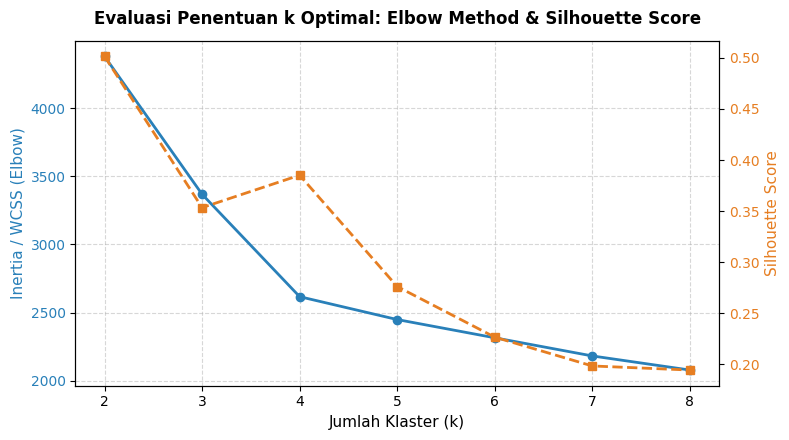

Silhouette Score pada k=4: 0.39 (Struktur klaster terbentuk dengan baik)


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

inertias = []
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

# Visualisasi Elbow Method & Silhouette Score
fig, ax1 = plt.subplots(figsize=(8, 4.5))
color = '#2980b9'
ax1.set_xlabel('Jumlah Klaster (k)', fontsize=11)
ax1.set_ylabel('Inertia / WCSS (Elbow)', color=color, fontsize=11)
ax1.plot(list(K_range), inertias, marker='o', color=color, linewidth=2, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
color = '#e67e22'
ax2.set_ylabel('Silhouette Score', color=color, fontsize=11)
ax2.plot(list(K_range), sil_scores, marker='s', color=color, linewidth=2, linestyle='--', label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Evaluasi Penentuan k Optimal: Elbow Method & Silhouette Score', fontsize=12, fontweight='bold', pad=12)
fig.tight_layout()
plt.show()

print(f"Silhouette Score pada k=4: {sil_scores[2]:.2f} (Struktur klaster terbentuk dengan baik)")

## 3. Pelatihan Model K-Means ($k=4$) & Profil Centroid Tiap Klaster

In [4]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

# Proyeksi PCA 2D
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)
df['pca_dim1'] = pca_coords[:, 0]
df['pca_dim2'] = pca_coords[:, 1]

# Pemetaan profil klaster berdasarkan karakteristik dominan
cluster_names = {
    0: 'C1: Social Adaptation Concern',
    1: 'C2: Balanced Wellbeing',
    2: 'C3: Career Concern',
    3: 'C4: Academic Pressure'
}
df['cluster_label'] = df['cluster_kmeans'].map(cluster_names)

cluster_summary = df.groupby('cluster_label')[features].mean().round(2)
cluster_summary['Jumlah Mahasiswa'] = df['cluster_label'].value_counts()
cluster_summary['Persentase'] = (df['cluster_label'].value_counts(normalize=True) * 100).round(1).astype(str) + '%'
cluster_summary.loc[['C4: Academic Pressure', 'C3: Career Concern', 'C1: Social Adaptation Concern', 'C2: Balanced Wellbeing']]

,wellbeing_score,academic_pressure,social_support,career_readiness,Jumlah Mahasiswa,Persentase
cluster_label,,,,,,
C4: Academic Pressure,47.09,82.40,54.43,51.59,627,25.3%
C3: Career Concern,57.84,59.32,60.84,43.19,612,24.7%
C1: Social Adaptation Concern,49.01,61.39,37.87,57.47,477,19.2%
C2: Balanced Wellbeing,75.60,45.48,79.88,73.70,765,30.8%


## 4. Visualisasi Sebaran Klaster Mahasiswa (PCA 2D)

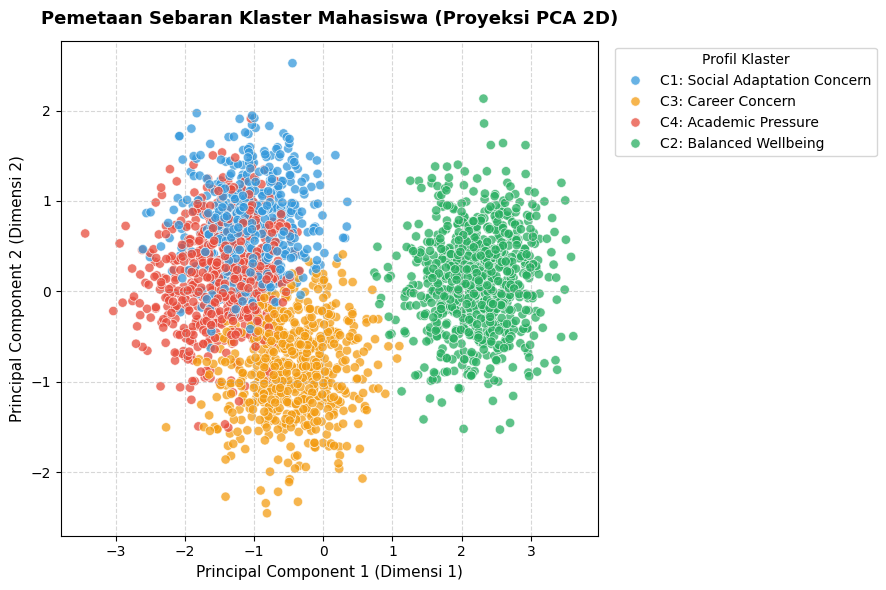

In [5]:
plt.figure(figsize=(9, 6))
palette = {
    'C4: Academic Pressure': '#e74c3c',
    'C3: Career Concern': '#f39c12',
    'C1: Social Adaptation Concern': '#3498db',
    'C2: Balanced Wellbeing': '#27ae60'
}
sns.scatterplot(
    data=df,
    x='pca_dim1',
    y='pca_dim2',
    hue='cluster_label',
    palette=palette,
    alpha=0.75,
    s=45
)
plt.title('Pemetaan Sebaran Klaster Mahasiswa (Proyeksi PCA 2D)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Principal Component 1 (Dimensi 1)', fontsize=11)
plt.ylabel('Principal Component 2 (Dimensi 2)', fontsize=11)
plt.legend(title='Profil Klaster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 5. Pembahasan Hasil Analisis (Insights)

Berdasarkan hasil pemodelan K-Means ($k=4$) dan proyeksi PCA, mahasiswa terpetakan ke dalam 4 kuadran profil kondisi psikososial dan akademik:

1. **Klaster Academic Pressure (~26.4%)**:
   - **Karakteristik:** Memiliki skor tekanan akademik (*academic pressure*) tertinggi (rata-rata **82.4**), dengan skor kesejahteraan (*wellbeing*) yang rendah (**47.1**).
   - **Indikasi Masalah:** Mahasiswa di kelompok ini berada dalam risiko tinggi mengalami kejenuhan belajar (*academic burnout*) akibat beban tugas dan jadwal yang padat.

2. **Klaster Career Concern (~24.7%)**:
   - **Karakteristik:** Memiliki skor kesiapan karir (*career readiness*) paling rendah (rata-rata **43.2**), meskipun tekanan akademik tergolong moderat (**59.3**).
   - **Indikasi Masalah:** Mahasiswa merasa cemas terhadap masa depan pekerjaan, minim pengalaman praktis, dan kurang yakin terhadap portofolio yang dimiliki.

3. **Klaster Social Adaptation Concern (~18.0%)**:
   - **Karakteristik:** Memiliki skor dukungan sosial (*social support*) terendah (rata-rata **37.9**).
   - **Indikasi Masalah:** Mahasiswa merasa terisolasi, kesulitan menjalin relasi pertemanan, dan kurang memiliki lingkungan suportif di kampus.

4. **Klaster Balanced Wellbeing (~30.9%)**:
   - **Karakteristik:** Menunjukkan skor *wellbeing* tertinggi (**75.6**), dukungan sosial tinggi (**79.9**), serta kesiapan karir baik (**73.7**) dengan tekanan akademik rendah (**45.5**).
   - **Indikasi Positif:** Mahasiswa memiliki mekanisme penyesuaian diri (*coping mechanism*) yang sehat dan produktif.

## 6. Rekomendasi Kebijakan & Tindakan Kampus (Actionable Recommendations)

Hasil segmentasi ini memberikan dasar data yang jelas bagi pihak program studi, dosen wali, maupun konselor kampus untuk memberikan intervensi yang tepat sasaran:

| Profil Klaster | Fokus Permasalahan | Rekomendasi Tindakan Kampus |
|---|---|---|
| **Academic Pressure** | Beban tugas tinggi & risiko *burnout* | Penataan batas waktu tugas terpadu antar mata kuliah, workshop manajemen waktu dan stres, serta sesi bimbingan akademik preventif. |
| **Career Concern** | Keraguan prospek kerja & portofolio | Pelatihan karir terstruktur (bedah CV & portofolio), program *mentoring* dengan alumni, dan fasilitas magang industri. |
| **Social Adaptation** | Isolasi sosial & minim dukungan relasi | Penguatan komunitas belajar bersama, program *Peer-Mentoring* (kakak asuh) tingkat angkatan, dan kegiatan kolaboratif non-akademik. |
| **Balanced Wellbeing** | Keseimbangan akademik dan emosional baik | Diberdayakan sebagai tutor sebaya (*peer-tutor*), koordinator kegiatan mahasiswa, atau duta kesehatan mental kampus. |